<a href="https://colab.research.google.com/github/Panini783/machineLearn/blob/main/%D0%9B%D0%A03_%D0%A1%D0%BB%D1%8E%D1%81%D0%B0%D1%80_%D0%A4%D0%86%D0%A23_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [10]:
# Ваш код:
# Імпортуйте pandas, numpy, matplotlib.pyplot, seaborn та інші потрібні бібліотеки.

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os



## 2. Завантаження даних
Оберіть **один** зі способів завантаження датасету.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [7]:
# Ваш код:
# Завантажте файл і збережіть дані у DataFrame `df`.
from google.colab import files

uploaded = files.upload()
csv_name = [name for name in uploaded if name.endswith('.csv')][0]
df = pd.read_csv(csv_name)
print(f'Завантажено файл: {csv_name}')
print(f'Розмір датасету: {df.shape}')
df.head()



Saving house_price_regression_dataset.csv to house_price_regression_dataset (3).csv
Завантажено файл: house_price_regression_dataset (3).csv
Розмір датасету: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path,"house_price_regression_dataset.csv"))
df.head()

Using Colab cache for faster access to the 'home-value-insights' dataset.
Path to dataset files: /kaggle/input/home-value-insights


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [12]:
# Ваш код:
# Виведіть кілька перших рядків та загальну інформацію про DataFrame.
display(df.head())
df.info()
print('Дублікати:', df.duplicated().sum())
display(df.isna().sum().to_frame('Кількість пропусків'))
display(df.describe().T)




,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB
Дублікати: 0


,Кількість пропусків
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


,count,mean,std,min,25%,50%,75%,max
Square_Footage,1000.0,2815.422000,1255.514921,503.000000,1749.500000,2862.500000,3849.500000,4.999000e+03
Num_Bedrooms,1000.0,2.990000,1.427564,1.000000,2.000000,3.000000,4.000000,5.000000e+00
Num_Bathrooms,1000.0,1.973000,0.820332,1.000000,1.000000,2.000000,3.000000,3.000000e+00
Year_Built,1000.0,1986.550000,20.632916,1950.000000,1969.000000,1986.000000,2004.250000,2.022000e+03
Lot_Size,1000.0,2.778087,1.297903,0.506058,1.665946,2.809740,3.923317,4.989303e+00
Garage_Size,1000.0,1.022000,0.814973,0.000000,0.000000,1.000000,2.000000,2.000000e+00
Neighborhood_Quality,1000.0,5.615000,2.887059,1.000000,3.000000,6.000000,8.000000,1.000000e+01
House_Price,1000.0,618861.018647,253568.058375,111626.853424,401648.228909,628267.291129,827141.277637,1.108237e+06


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [13]:
# Ваш код:
# Порахуйте кількість дублікатів.
# Перевірка дублікатів
num_duplicates = df.duplicated().sum()
print(f'Кількість дубльованих рядків: {num_duplicates}')




Кількість дубльованих рядків: 0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [14]:
# Ваш код:
# Виведіть кількість пропусків для кожної ознаки.

# К-ть пропущених значень у кожному стовпці
print('Пропущені значення:')
display(df.isna().sum().to_frame('Кількість пропусків'))

# Або у вигляді відсотків
print('\nВідсоток пропусків:')
display((df.isna().sum() / len(df) * 100).to_frame('Відсоток %'))



Пропущені значення:


,Кількість пропусків
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0



Відсоток пропусків:


,Відсоток %
Square_Footage,0.0
Num_Bedrooms,0.0
Num_Bathrooms,0.0
Year_Built,0.0
Lot_Size,0.0
Garage_Size,0.0
Neighborhood_Quality,0.0
House_Price,0.0


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [16]:
# Ваш код:
# Отримайте описову статистику датасету.
display(df.describe())

# Додатково: медіана та інші квантилі
display(df.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).T)




,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


,count,mean,std,min,25%,50%,75%,90%,95%,max
Square_Footage,1000.0,2815.422000,1255.514921,503.000000,1749.500000,2862.500000,3849.500000,4557.400000,4.743300e+03,4.999000e+03
Num_Bedrooms,1000.0,2.990000,1.427564,1.000000,2.000000,3.000000,4.000000,5.000000,5.000000e+00,5.000000e+00
Num_Bathrooms,1000.0,1.973000,0.820332,1.000000,1.000000,2.000000,3.000000,3.000000,3.000000e+00,3.000000e+00
Year_Built,1000.0,1986.550000,20.632916,1950.000000,1969.000000,1986.000000,2004.250000,2015.000000,2.018000e+03,2.022000e+03
Lot_Size,1000.0,2.778087,1.297903,0.506058,1.665946,2.809740,3.923317,4.544758,4.743804e+00,4.989303e+00
Garage_Size,1000.0,1.022000,0.814973,0.000000,0.000000,1.000000,2.000000,2.000000,2.000000e+00,2.000000e+00
Neighborhood_Quality,1000.0,5.615000,2.887059,1.000000,3.000000,6.000000,8.000000,10.000000,1.000000e+01,1.000000e+01
House_Price,1000.0,618861.018647,253568.058375,111626.853424,401648.228909,628267.291129,827141.277637,967336.919138,1.010648e+06,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [17]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Neighborhood_Quality`.

neighborhood_counts = df['Neighborhood_Quality'].value_counts().sort_index()

display(neighborhood_counts)



,count
Neighborhood_Quality,
1,91
2,105
3,85
4,99
5,109
6,101
7,102
8,97
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

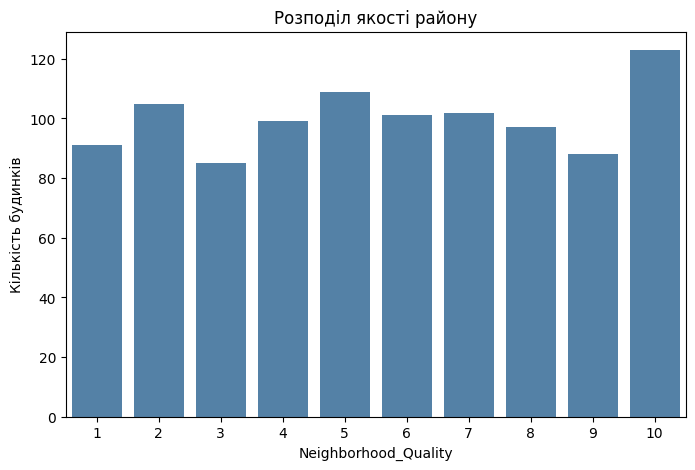

In [18]:
# Ваш код:
# Побудуйте countplot або іншу відповідну діаграму.

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Neighborhood_Quality', color='steelblue')
plt.title('Розподіл якості району')
plt.xlabel('Neighborhood_Quality')
plt.ylabel('Кількість будинків')
plt.xticks(rotation=0)
plt.show()



### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [19]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Num_Bathrooms`.
bathroom_counts = df['Num_Bathrooms'].value_counts().sort_index()

display(bathroom_counts)



,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

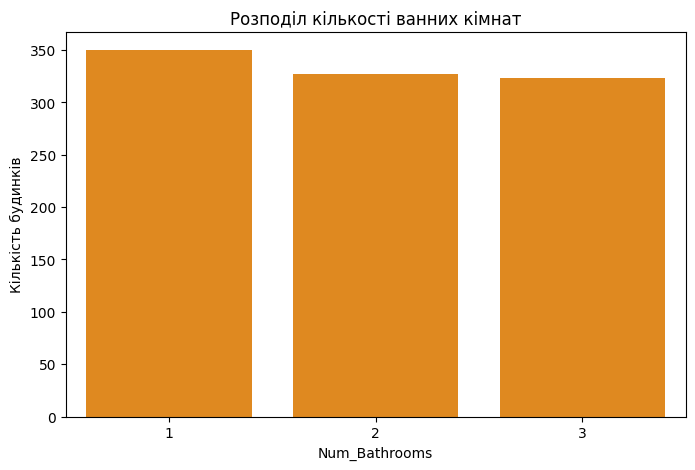

In [20]:
# Ваш код:
# Побудуйте відповідну діаграму.
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Num_Bathrooms', color='darkorange')
plt.title('Розподіл кількості ванних кімнат')
plt.xlabel('Num_Bathrooms')
plt.ylabel('Кількість будинків')
plt.xticks(rotation=0)
plt.show()




### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

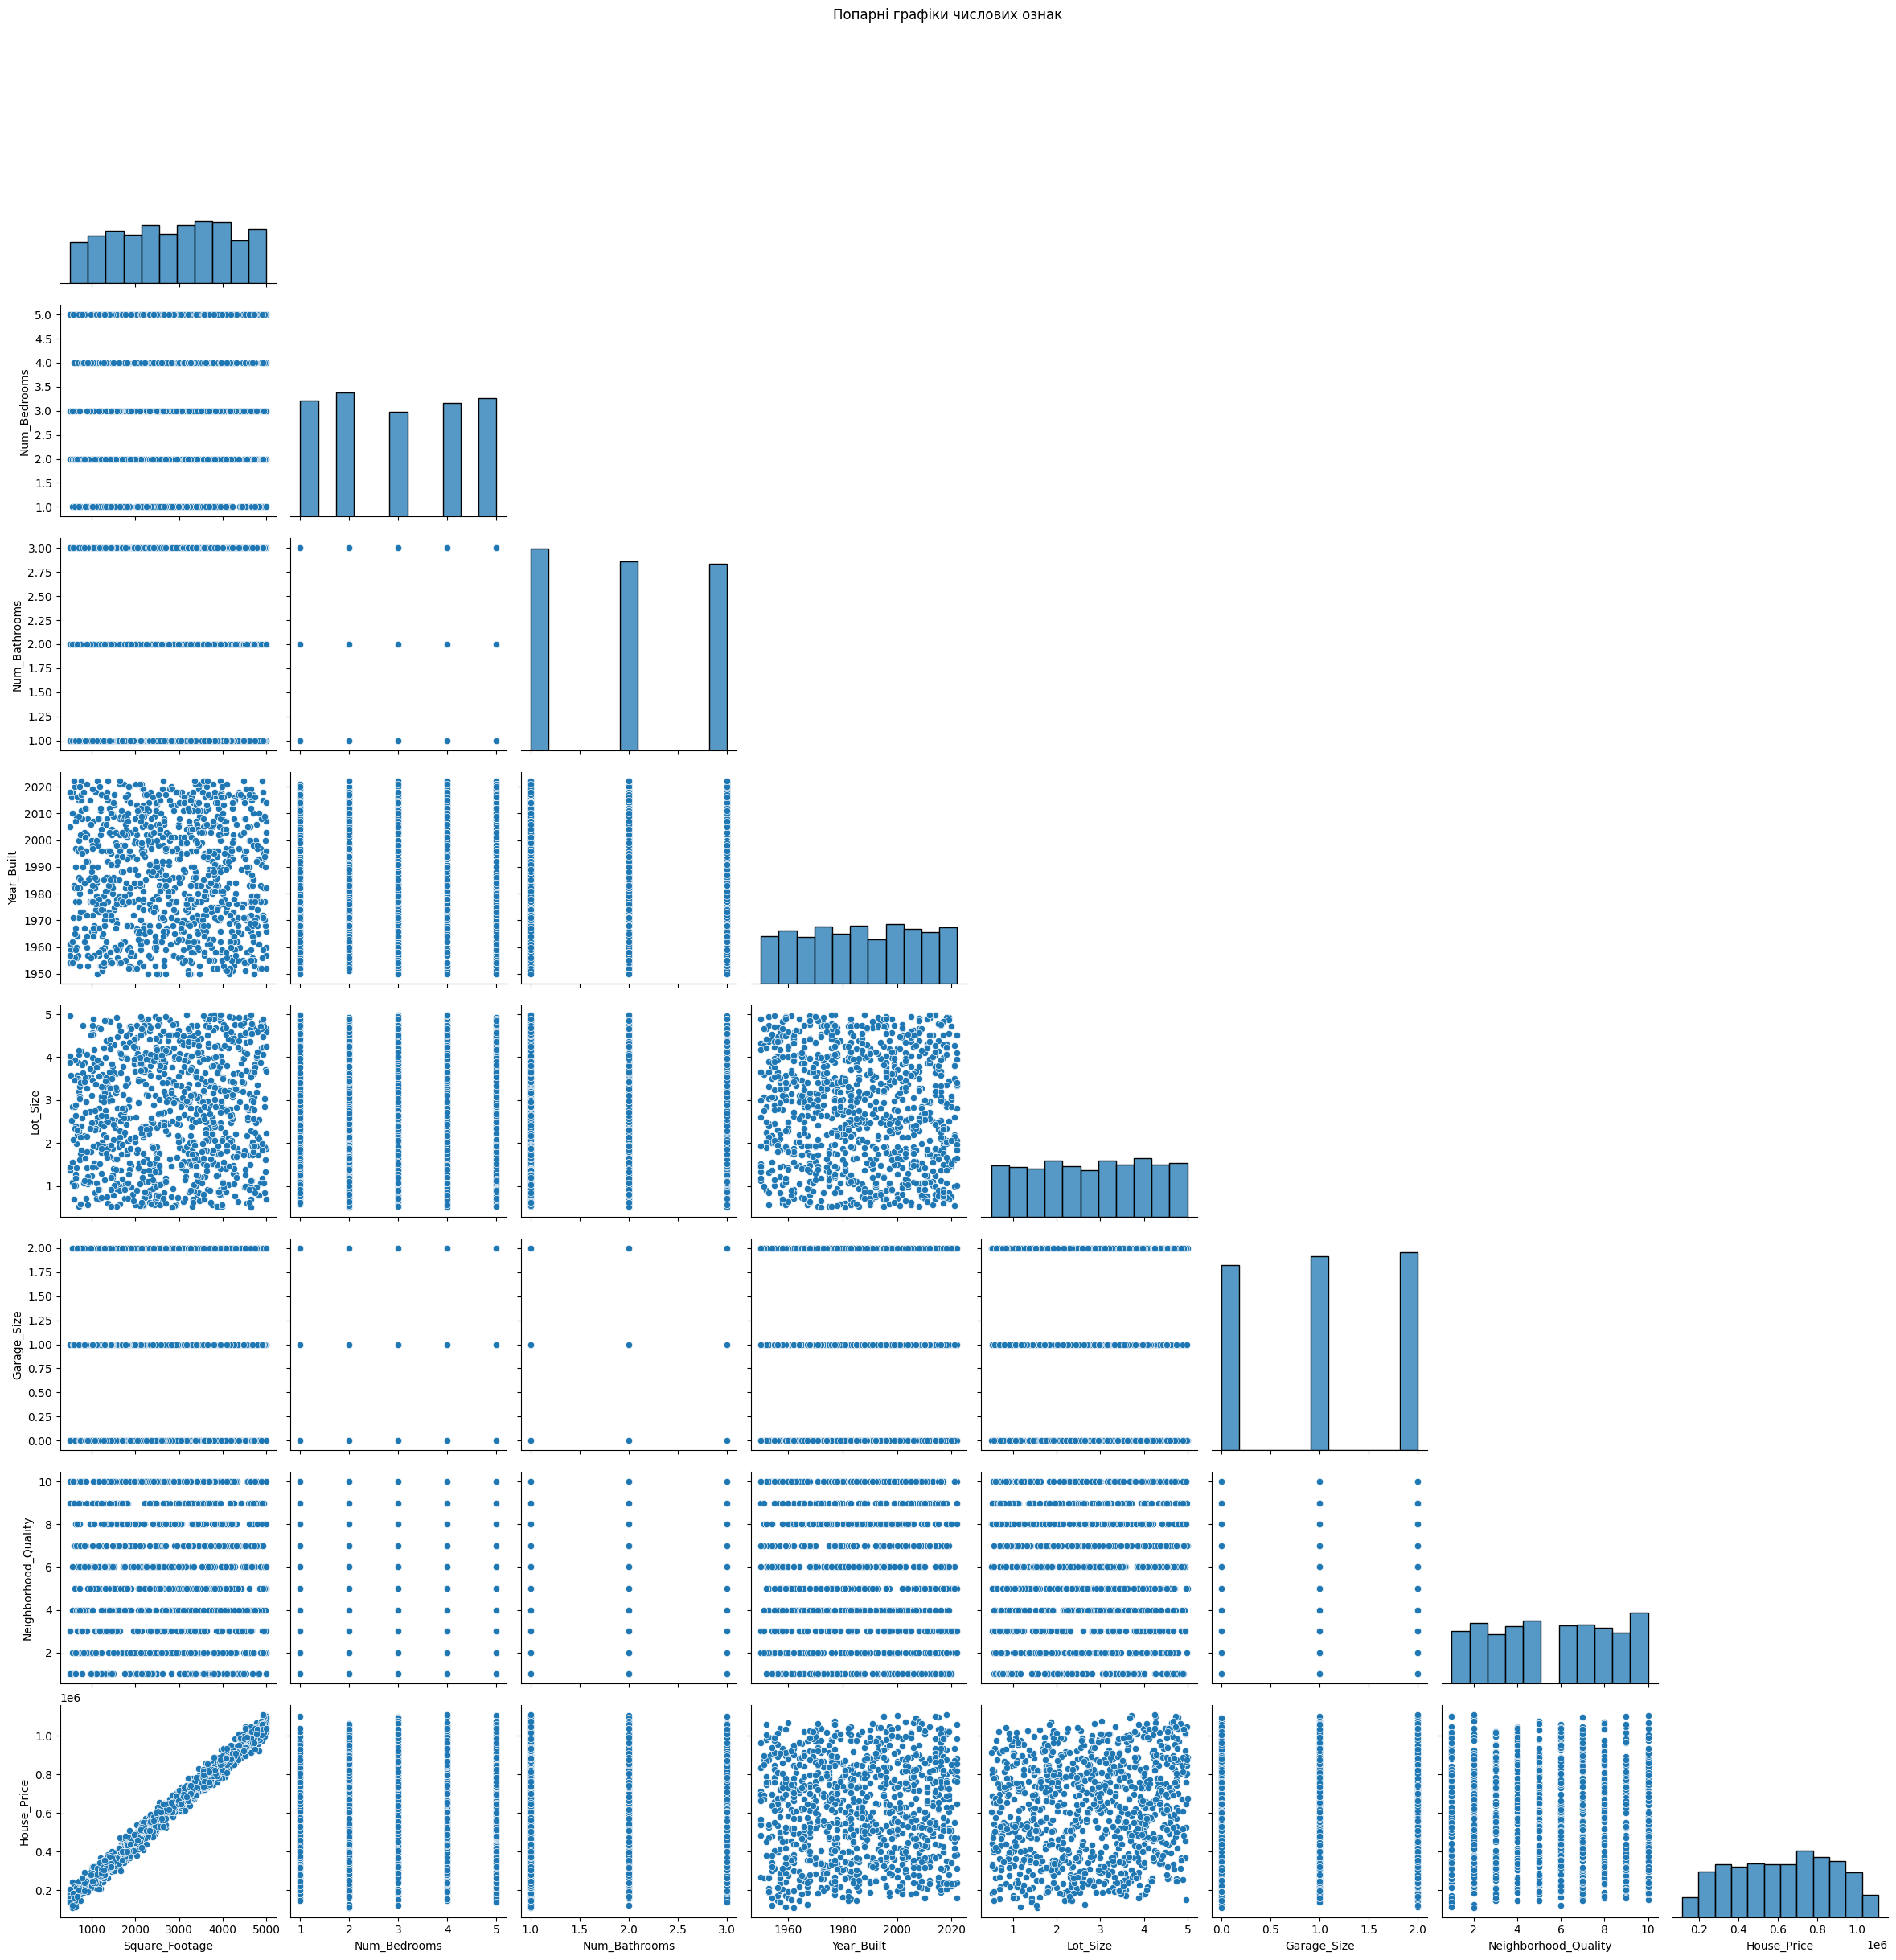

In [21]:
# Ваш код:
# Побудуйте pairplot або іншу попарну візуалізацію.
numeric_cols = [
    'Square_Footage',
    'Num_Bedrooms',
    'Num_Bathrooms',
    'Year_Built',
    'Lot_Size',
    'Garage_Size',
    'Neighborhood_Quality',
    'House_Price'
]

# Побудова попарних графіків
sns.pairplot(df[numeric_cols], corner=True, height=3)
plt.suptitle('Попарні графіки числових ознак', y=1.02)
plt.show()




## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

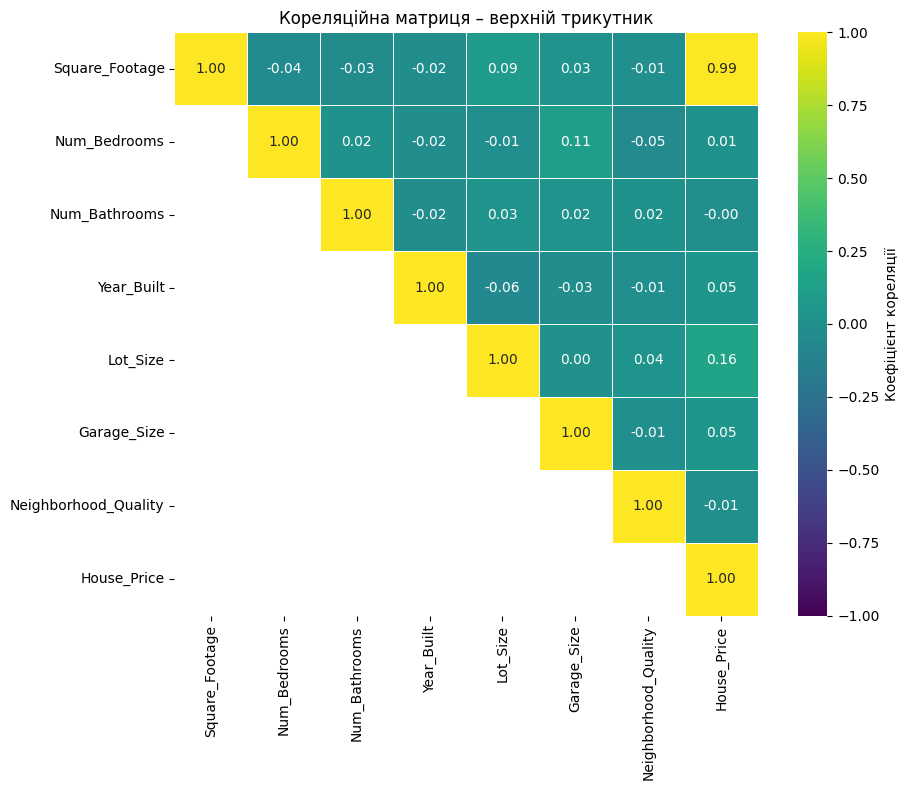

In [43]:
# Ваш код:
# Обчисліть кореляційну матрицю та побудуйте heatmap.
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Коефіцієнт кореляції'}
)

plt.title('Кореляційна матриця – верхній трикутник')
plt.tight_layout()
plt.show()




### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [23]:
# Ваш код:
# Виведіть кореляції ознак із `House_Price`.
numeric_df = df.select_dtypes(include=np.number)

# Кореляція кожної ознаки з House_Price
corr_with_price = numeric_df.corr()['House_Price'].sort_values(ascending=False)

display(corr_with_price.to_frame('Кореляція з House_Price'))




,Кореляція з House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [30]:
# Ваш код:
# Імпортуйте необхідні класи та функції зі scikit-learn.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [31]:
# Ваш код:
# Створіть `X` та `y`.
X = df.drop(columns='House_Price')

# Цільова змінна
y = df['House_Price']

print('Розмірність X:', X.shape)
print('Розмірність y:', y.shape)




Розмірність X: (1000, 7)
Розмірність y: (1000,)


### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [32]:
# Ваш код:
# Створіть `X_train`, `X_test`, `y_train`, `y_test`.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Розмір навчальної вибірки X_train:', X_train.shape)
print('Розмір тестової вибірки X_test:', X_test.shape)
print('Розмір навчальної вибірки y_train:', y_train.shape)
print('Розмір тестової вибірки y_test:', y_test.shape)



Розмір навчальної вибірки X_train: (800, 7)
Розмір тестової вибірки X_test: (200, 7)
Розмір навчальної вибірки y_train: (800,)
Розмір тестової вибірки y_test: (200,)


### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [34]:
# Ваш код:
# Створіть словник або іншу структуру з п’ятьма моделями.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=1.0, max_iter=10000))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )
}



### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [35]:
# Ваш код:
# Навчіть усі моделі, отримайте прогнози та метрики на тестовій вибірці.
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = []
predictions = {}

for name, model in models.items():
    # Навчаємо модель
    model.fit(X_train, y_train)

    # Отримуємо прогноз на тестовій вибірці
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Зберігаємо метрики
    results.append({
        'Model': name,
        'R2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred)
    })

# Таблиця для порівняння моделей
results_df = pd.DataFrame(results).sort_values(
    by='R2', ascending=False
).reset_index(drop=True)

display(results_df.round(4))




,Model,R2,MAE,MSE
0,Linear Regression,0.9984,8174.5836,1.014348e+08
1,Lasso,0.9984,8174.7484,1.014366e+08
2,Ridge,0.9984,8241.5869,1.024810e+08
3,Gradient Boosting,0.9969,11409.0816,1.966456e+08
4,Random Forest,0.9940,16035.1681,3.872291e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

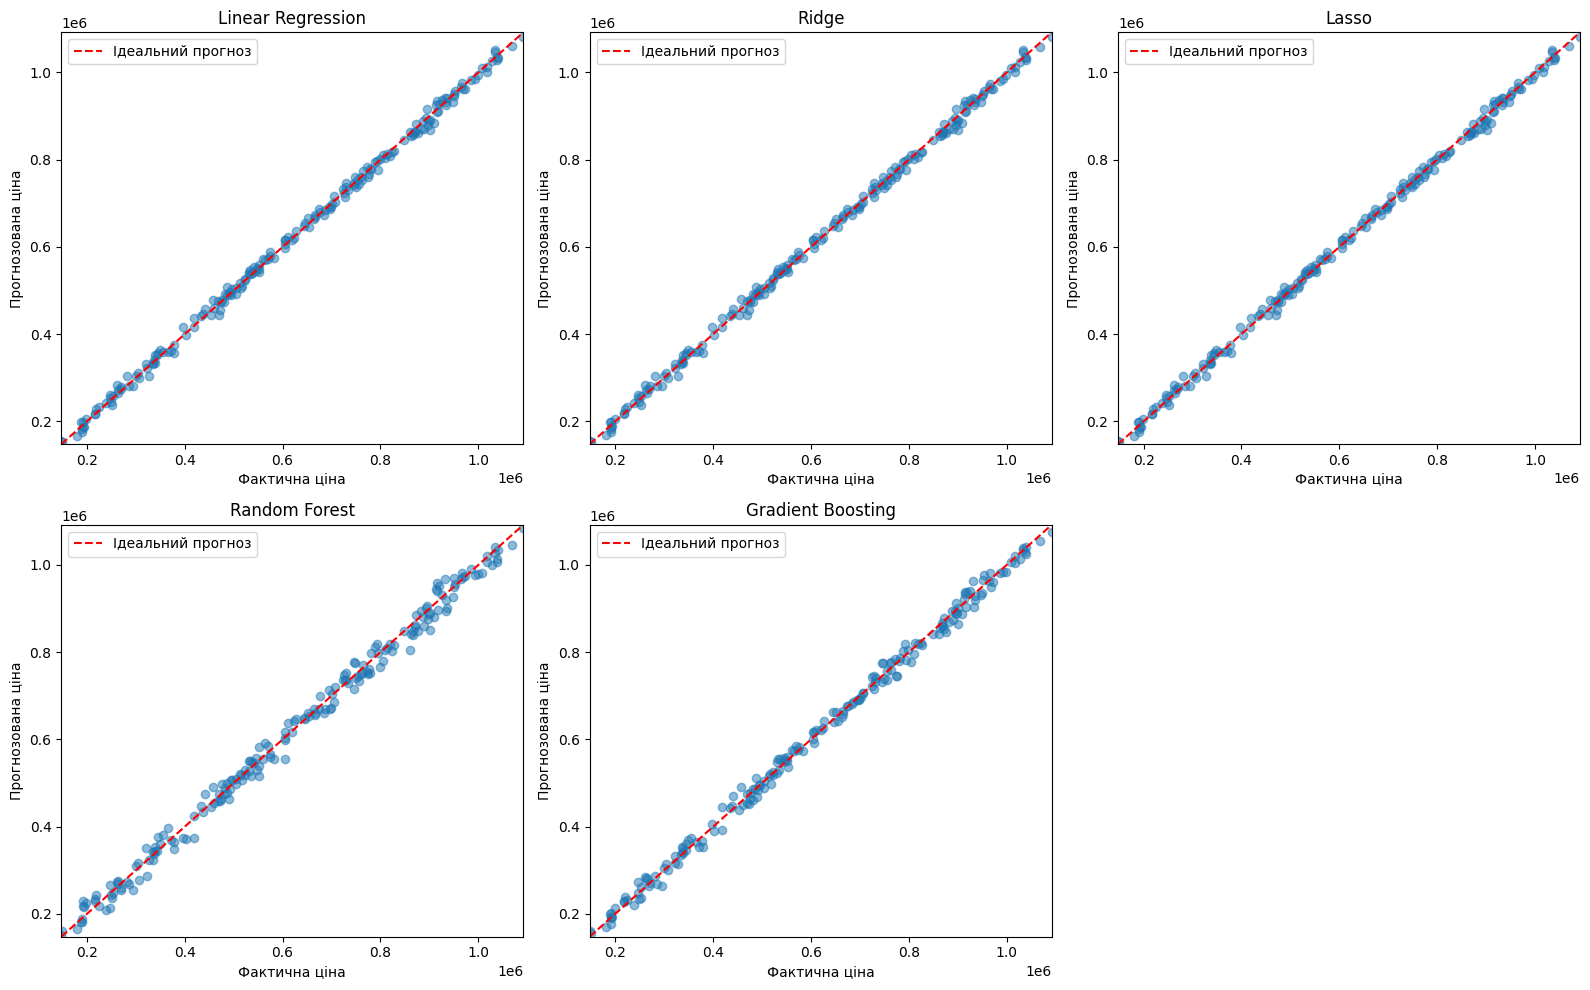

In [36]:
# Ваш код:
# Побудуйте окремий графік для кожної моделі.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.5)

    # Однакові межі для обох осей і лінія ідеального прогнозу
    lower = min(y_test.min(), y_pred.min())
    upper = max(y_test.max(), y_pred.max())
    ax.plot([lower, upper], [lower, upper], 'r--', label='Ідеальний прогноз')

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_title(name)
    ax.set_xlabel('Фактична ціна')
    ax.set_ylabel('Прогнозована ціна')
    ax.legend()

# Шоста комірка не потрібна — моделей п’ять
axes[-1].axis('off')

plt.tight_layout()
plt.show()




## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [38]:
# Ваш код:
# Створіть сітку параметрів, GridSearchCV і знайдіть найкращі параметри.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_features': [1.0, 'sqrt'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Найкращі параметри:', grid_search.best_params_)
print(f'Найкраще середнє R² на крос-валідації: {grid_search.best_score_:.4f}')




Fitting 5 folds for each of 24 candidates, totalling 120 fits
Найкращі параметри: {'max_depth': None, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 200}
Найкраще середнє R² на крос-валідації: 0.9920


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [39]:
# Ваш код:
# Навчіть оптимізований Random Forest та обчисліть метрики.

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Створюємо нову модель із параметрами, знайденими GridSearchCV
optimized_rf = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

# Навчаємо лише на навчальній вибірці
optimized_rf.fit(X_train, y_train)

# Прогнозуємо ціни на тестовій вибірці
optimized_pred = optimized_rf.predict(X_test)

# Обчислюємо метрики
optimized_metrics = {
    'R2': r2_score(y_test, optimized_pred),
    'MAE': mean_absolute_error(y_test, optimized_pred),
    'MSE': mean_squared_error(y_test, optimized_pred)
}

print('Найкращі параметри:', grid_search.best_params_)
print(f"R²:  {optimized_metrics['R2']:.4f}")
print(f"MAE: {optimized_metrics['MAE']:.2f}")
print(f"MSE: {optimized_metrics['MSE']:.2f}")



Найкращі параметри: {'max_depth': None, 'max_features': 1.0, 'min_samples_split': 2, 'n_estimators': 200}
R²:  0.9940
MAE: 16035.17
MSE: 387229091.92


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [40]:
# Ваш код:
# Виведіть результати двох моделей у зручному для порівняння вигляді.
base_rf = results_df.loc[
    results_df['Model'] == 'Random Forest',
    ['R2', 'MAE', 'MSE']
].iloc[0]

# Метрики оптимізованої моделі із завдання 18
comparison = pd.DataFrame({
    'Базовий Random Forest': base_rf,
    'Оптимізований Random Forest': pd.Series(optimized_metrics)
}).T

display(comparison.round(4))




,R2,MAE,MSE
Базовий Random Forest,0.994,16035.1681,3.872291e+08
Оптимізований Random Forest,0.994,16035.1681,3.872291e+08


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**
Після підбору гіперпараметрів Random Forest помітного покращення на тестовій вибірці не спостерігається. Для базової та оптимізованої моделей R² становить 0,994, MAE — 16 035,1681, а MSE — приблизно
3,872291
×
10
8
3,872291×10
8
. Отже, за наведеними метриками оптимізована модель не має переваги над базовою; доцільніше використовувати базову модель, оскільки додатковий підбір параметрів не дав видимого виграшу.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [41]:
# Ваш код:
# Сформуйте DataFrame з фактичними та прогнозованими значеннями і розрахуйте похибку у %.
forecast_table = pd.DataFrame({
    'Фактична ціна': y_test.to_numpy(),
    'Прогнозована ціна': predictions['Linear Regression']
})

# Абсолютна відносна похибка для кожного будинку
forecast_table['Похибка, %'] = np.where(
    forecast_table['Фактична ціна'] != 0,
    (
        np.abs(forecast_table['Фактична ціна']
               - forecast_table['Прогнозована ціна'])
        / np.abs(forecast_table['Фактична ціна'])
    ) * 100,
    np.nan
)

display(forecast_table.sample(n=10, random_state=42).round(2))




,Фактична ціна,Прогнозована ціна,"Похибка, %"
95,1068538.11,1059729.02,0.82
15,194353.74,187868.55,3.34
30,270230.64,279715.82,3.51
158,986006.86,981949.27,0.41
128,953339.73,957382.95,0.42
115,914555.75,909764.27,0.52
69,746167.73,742469.14,0.50
170,646766.29,654445.55,1.19
174,523323.07,524605.44,0.25
45,1008539.16,1011343.64,0.28


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**
У лабораторній роботі було побудовано п’ять моделей регресії: Linear Regression, Ridge, Lasso, Random Forest Regressor і Gradient Boosting Regressor. Найкращий результат на тестовій вибірці показала Linear Regression: R² = 0,9984, MAE = 8174,5836, MSE ≈
1,014348
×
10
8
1,014348×10
8
. Lasso та Ridge також досягли R² ≈ 0,9984, проте їхні похибки були дещо більшими.

Підбір гіперпараметрів Random Forest не дав помітного покращення: базова й оптимізована моделі показали однакові метрики з точністю відображення — R² = 0,9940, MAE = 16035,1681, MSE ≈
3,872291
×
10
8
3,872291×10
8
. Отже, за результатами цього дослідження доцільніше використовувати Linear Regression.

Значення R² = 0,9984 свідчить про дуже високу якість прогнозування на виділеній тестовій вибірці. Середня абсолютна похибка найкращої моделі становить приблизно 8175 одиниць ціни датасету. На точність прогнозів можуть впливати площа будинку й ділянки, кількість спалень і ванних кімнат, рік побудови, розмір гаража та якість району. Висновок про перевагу Linear Regression стосується саме цього датасету й обраного поділу на навчальну та тестову вибірки.